# Análise Tática e Estatística: Transição de Comando no Cruzeiro
**Tite vs. Arthur Jorge: Impactos na Criação, Finalização e Utilização da Base**

**Autor:** Felipe Almeida Pereira  
**Data:** Agosto de 2026  

---

## Resumo 
Este projeto tem como objetivo analisar quantitativa e espacialmente as mudanças táticas ocorridas no Cruzeiro após a troca de comando técnico (Tite para Arthur Jorge). Utilizando dados de eventos extraídos da plataforma Sofascore, investigamos:
1. **Dinâmica de Meio-Campo:** O reposicionamento espacial de peças-chave na construção das jogadas.
2. **Agressividade e Criação:** A evolução na progressão de passes e passes decisivos para o terço final.
3. **Qualidade Ofensiva:** O salto qualitativo nas chances criadas, medido através de Gols Esperados (xG) e Assistências Esperadas (xA).
4. **Gestão de Ativos (Base):** O impacto direto na minutagem de atletas da categoria Sub-23 em um recorte idêntico de partidas.

## 1. Preparação do Ambiente
Instalação das bibliotecas necessárias para manipulação de dados, web scraping e desenho dos campos de futebol (pitches).

In [ ]:
# Instalação das bibliotecas 
!pip install requests pandas matplotlib seaborn mplsoccer
!pip install cloudscraper

import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mplsoccer import Pitch

---
## 2. Análise Espacial: O Reposicionamento de Gerson
Nesta primeira análise, extraímos as coordenadas de todos os passes realizados por Gerson em uma amostra de 8 jogos de cada treinador. 

O mapa de calor em estilo de densidade (*KDE Plot*) revela como o jogador atuava sob o comando de Tite e como o seu raio de ação foi alterado na Era Arthur Jorge, impactando a saída de bola da equipe.

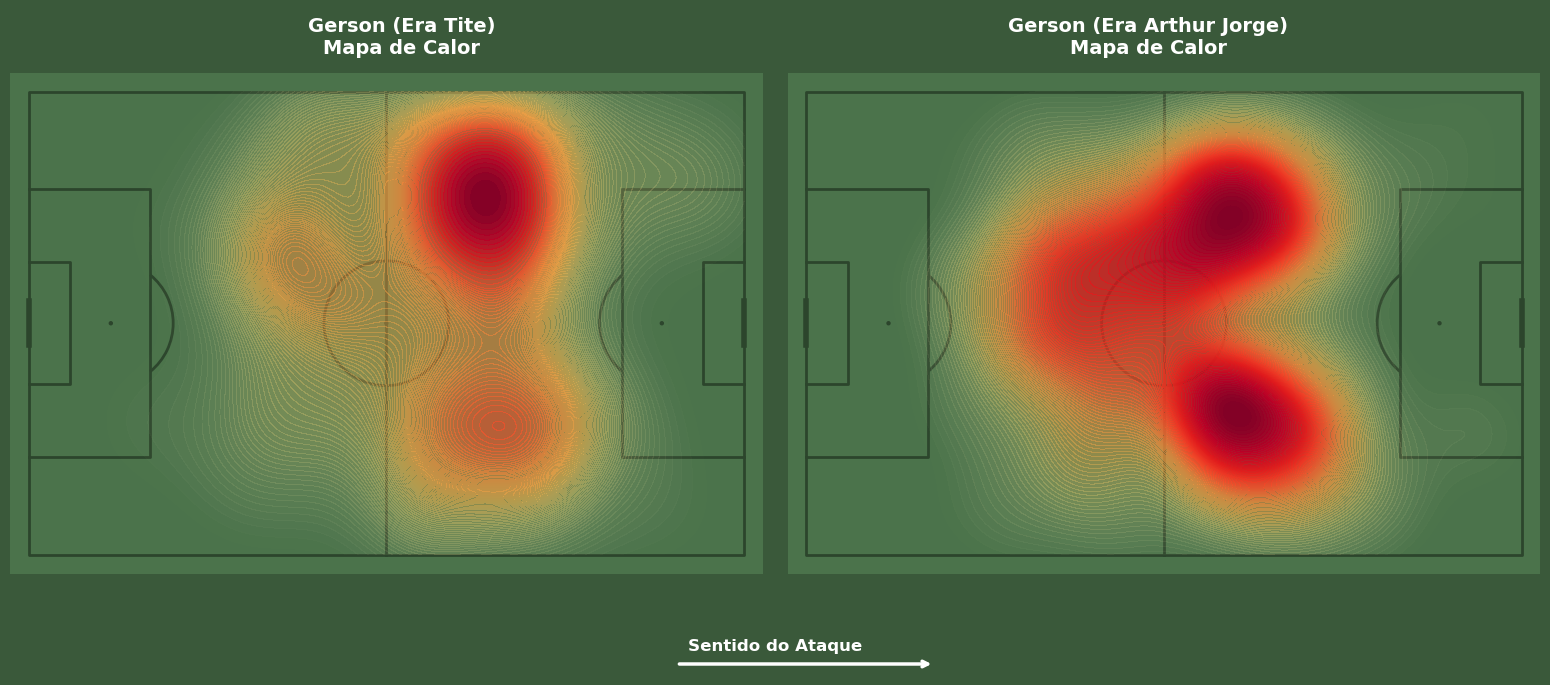

In [59]:
# Função para extrair os toques do Gerson (garantindo que os dados estejam na memória)
def extrair_toques(pasta, sigla, nome_busca):
    toques_x, toques_y = [], []
    for i in range(1, 9):
        caminho = os.path.join(pasta, f"jogo{i}_{sigla}_gerson_passes.json")
        if os.path.exists(caminho):
            with open(caminho, 'r', encoding='utf-8') as f:
                dados = json.load(f)
                for evento in dados.get('passes', []):
                    # Coleta apenas as posições iniciais (onde ele estava com a bola)
                    toques_x.append(evento['playerCoordinates']['x'])
                    toques_y.append(evento['playerCoordinates']['y'])
    return toques_x, toques_y

x_tt, y_tt = extrair_toques('dados_tite', 'tt', 'Gerson')
x_aj, y_aj = extrair_toques('dados_arthur', 'aj', 'Gerson')

# ==========================================
# DESIGN SOFASCORE (Verde, sem curvas de nível)
# ==========================================
cor_grama = '#4b734b'
cor_linha = '#2c452c'

pitch = Pitch(pitch_type='opta', pitch_color=cor_grama, line_color=cor_linha)
fig, axs = pitch.grid(ncols=2, title_height=0.08, endnote_space=0.08, axis=False, figheight=7)
fig.set_facecolor('#3a593a')

# Criando um mapa de calor que vai do Transparente -> Amarelo -> Laranja -> Vermelho
cmap_base = plt.cm.YlOrRd
meu_cmap = cmap_base(np.arange(cmap_base.N))
meu_cmap[:, -1] = np.linspace(0.0, 1.0, cmap_base.N) # Aplica o gradiente de transparência (Alpha)
cmap_sofascore = mcolors.ListedColormap(meu_cmap)

# Plot Era Tite
pitch.kdeplot(x_tt, y_tt, ax=axs['pitch'][0],
              cmap=cmap_sofascore,
              fill=True,
              levels=100,      # Deixa o calor perfeitamente esfumaçado
              thresh=0.02,     # Limite para ignorar áreas com quase nenhum toque
              cut=4)

# Plot Era Arthur Jorge
pitch.kdeplot(x_aj, y_aj, ax=axs['pitch'][1],
              cmap=cmap_sofascore,
              fill=True,
              levels=100,
              thresh=0.02,
              cut=4)

# Títulos
axs['title'].text(0.25, 0.5, 'Gerson (Era Tite)\nMapa de Calor', color='white', va='center', ha='center', fontsize=14, fontweight='bold')
axs['title'].text(0.75, 0.5, 'Gerson (Era Arthur Jorge)\nMapa de Calor', color='white', va='center', ha='center', fontsize=14, fontweight='bold')

# Adicionando a Seta e Texto de Sentido do Ataque no rodapé
fig.text(0.5, 0.06, 'Sentido do Ataque', color='white', ha='center', fontsize=12, fontweight='bold')
plt.annotate('', xy=(0.58, 0.03), xytext=(0.42, 0.03), xycoords='figure fraction',
             arrowprops=dict(arrowstyle="->", color='white', lw=2.5))

plt.show()

### Insights Táticos: O Comportamento de Gerson
* **Era Tite (Esquerda):** Observa-se uma concentração muito forte de toques e ações no campo defensivo e na primeira linha de construção, evidenciando que Gerson tinha um papel de maior retenção e saída profunda, muitas vezes pisando menos na zona de decisão.
* **Era Arthur Jorge (Direita):** O mapa mostra claramente uma expansão e um avanço no raio de ação do atleta. As manchas quentes sobem pelo campo, indicando maior liberdade para pisar no terço final e participar ativamente da construção ofensiva em zonas mais avançadas.

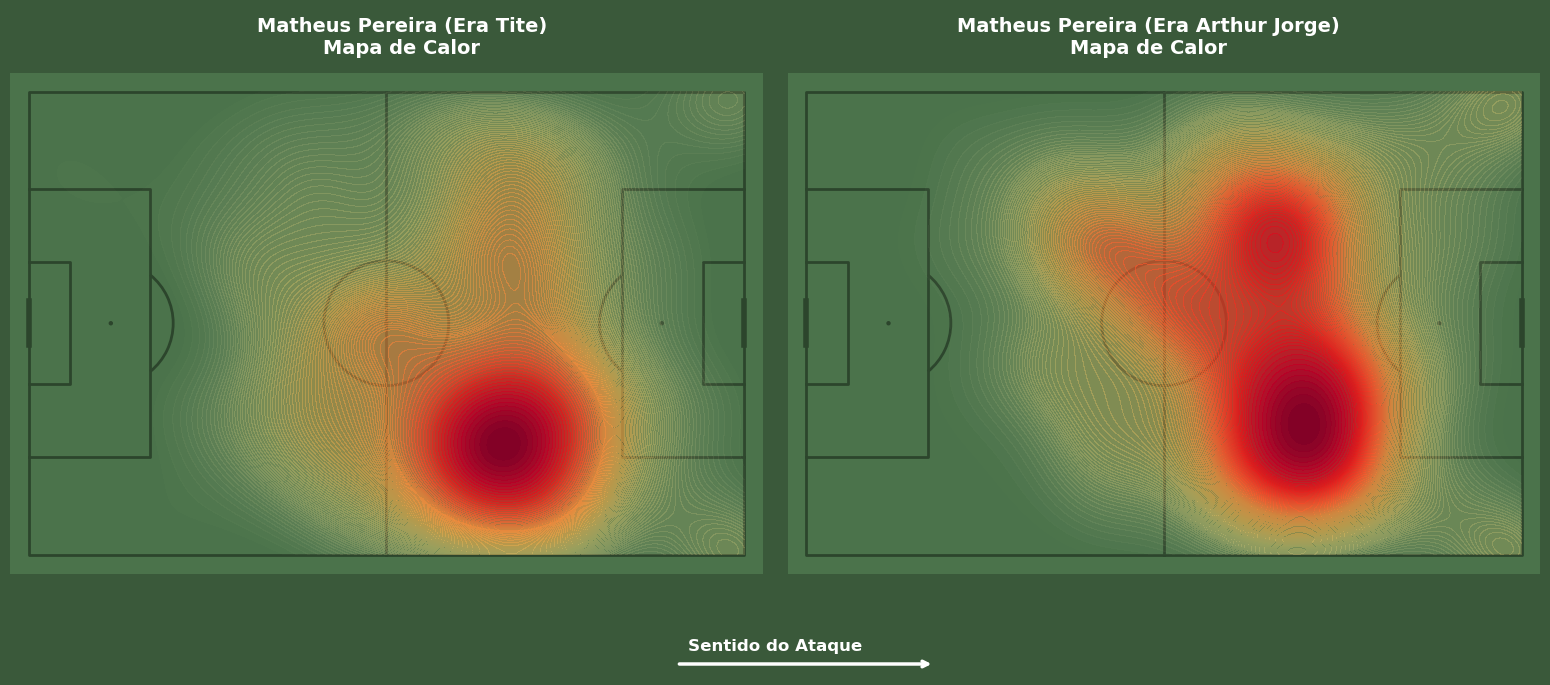

In [61]:
# ==========================================
# EXTRAINDO E DESENHANDO: MATHEUS PEREIRA (ESTILO SOFASCORE)
# ==========================================

# 1. Extraindo os dados agregados do Matheus Pereira usando a função anterior
x_tite_mp, y_tite_mp = agregar_coordenadas_heatmap('dados_tite', 'tt', 'matheus')
x_arthur_mp, y_arthur_mp = agregar_coordenadas_heatmap('dados_arthur', 'aj', 'matheus')

# 2. Configurando as cores do campo e criando o Colormap
cor_grama = '#4b734b'
cor_linha = '#2c452c'

pitch = Pitch(pitch_type='opta', pitch_color=cor_grama, line_color=cor_linha)
# endnote_space ajustado para caber a seta no rodapé
fig_mp, axs_mp = pitch.grid(ncols=2, title_height=0.08, endnote_space=0.08, axis=False, figheight=7)
fig_mp.set_facecolor('#3a593a')

# Reconstruindo o mapa de cores gradual (Transparente -> Amarelo -> Vermelho)
cmap_base = plt.cm.YlOrRd
meu_cmap = cmap_base(np.arange(cmap_base.N))
meu_cmap[:, -1] = np.linspace(0.0, 1.0, cmap_base.N)
cmap_sofascore = mcolors.ListedColormap(meu_cmap)

# 3. Plotando a Era Tite (Campo da Esquerda)
pitch.kdeplot(x_tite_mp, y_tite_mp, ax=axs_mp['pitch'][0], 
              cmap=cmap_sofascore, fill=True, levels=100, thresh=0.02, cut=4)
axs_mp['title'].text(0.25, 0.5, 'Matheus Pereira (Era Tite)\nMapa de Calor', 
                  color='white', va='center', ha='center', fontsize=14, fontweight='bold')

# 4. Plotando a Era Arthur Jorge (Campo da Direita)
pitch.kdeplot(x_arthur_mp, y_arthur_mp, ax=axs_mp['pitch'][1], 
              cmap=cmap_sofascore, fill=True, levels=100, thresh=0.02, cut=4)
axs_mp['title'].text(0.75, 0.5, 'Matheus Pereira (Era Arthur Jorge)\nMapa de Calor', 
                  color='white', va='center', ha='center', fontsize=14, fontweight='bold')

# 5. Adicionando a Seta e Texto de Sentido do Ataque no rodapé
fig_mp.text(0.5, 0.06, 'Sentido do Ataque', color='white', ha='center', fontsize=12, fontweight='bold')
plt.annotate('', xy=(0.58, 0.03), xytext=(0.42, 0.03), xycoords='figure fraction',
             arrowprops=dict(arrowstyle="->", color='white', lw=2.5))

plt.show()

### Insights Táticos: O Desafogo de Matheus Pereira
* **Era Tite (Esquerda):** Matheus Pereira ficava sobrecarregado, descendo muitas vezes para buscar a bola em zonas intermediárias/baixas por falta de opções de saída limpa, o que limitava sua presença na área adversária.
* **Era Arthur Jorge (Direita):** Com o ajuste posicional na saída de bola, Matheus ganha liberdade total de movimentação na entrelinha e na entrada da grande área, gerando focos de pressão ofensiva muito mais intensos e centralizados na zona de criação final.

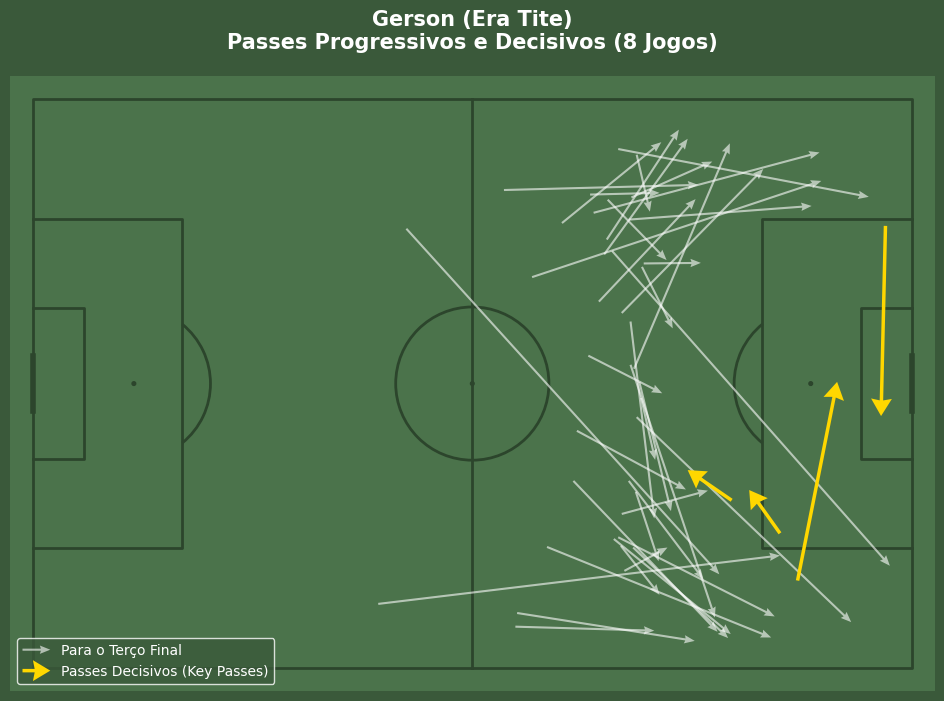

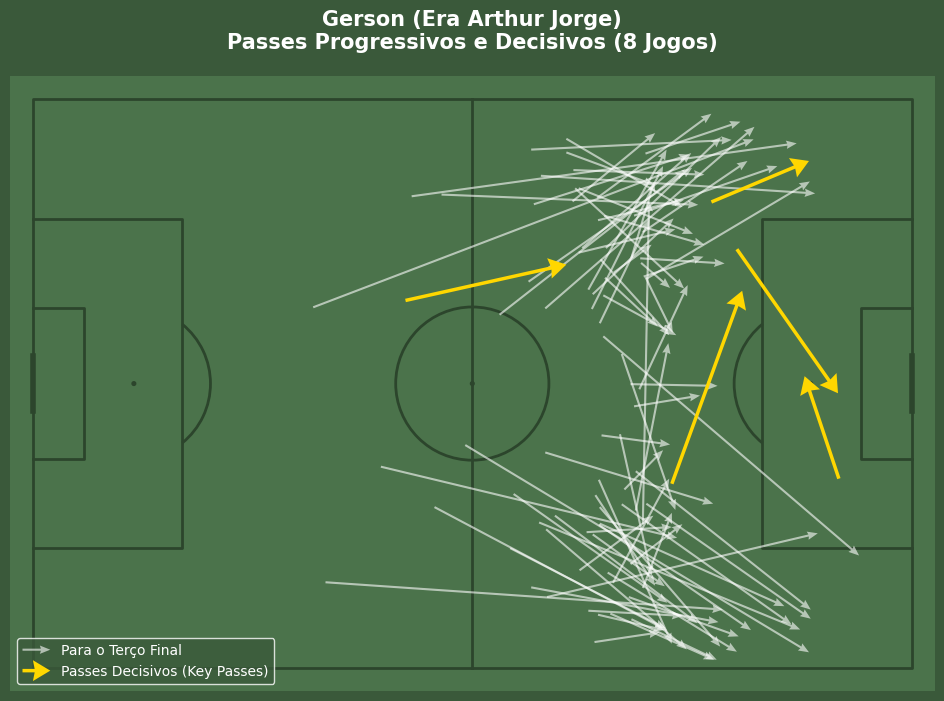

In [40]:
import os
import json
import matplotlib.pyplot as plt
from mplsoccer import Pitch

# ==========================================
# MAPA DE PASSES AGRESSIVOS: GERSON (AS DUAS ERAS)
# ==========================================

def plotar_passes_verticais_gerson(pasta, sigla, titulo):
    # Usando a paleta Sofascore para manter a identidade visual do projeto
    cor_grama = '#4b734b'
    cor_linha = '#2c452c'
    cor_fundo = '#3a593a'
    
    pitch = Pitch(pitch_type='opta', pitch_color=cor_grama, line_color=cor_linha)
    fig, ax = pitch.draw(figsize=(10, 7))
    fig.set_facecolor(cor_fundo)
    
    passes_x_ini, passes_y_ini, passes_x_fim, passes_y_fim = [], [], [], []
    key_x_ini, key_y_ini, key_x_fim, key_y_fim = [], [], [], []
    
    for i in range(1, 9):
        caminho = os.path.join(pasta, f"jogo{i}_{sigla}_gerson_passes.json")
        if os.path.exists(caminho):
            with open(caminho, 'r', encoding='utf-8') as f:
                dados = json.load(f)
                
                for evento in dados.get('passes', []):
                    # Filtrar apenas passes que deram certo
                    if evento.get('outcome') == True:
                        x_ini = evento['playerCoordinates']['x']
                        y_ini = evento['playerCoordinates']['y']
                        x_fim = evento['passEndCoordinates']['x']
                        y_fim = evento['passEndCoordinates']['y']
                        
                        # Destacar Passes Decisivos (Key Passes)
                        if evento.get('keypass') == True:
                            key_x_ini.append(x_ini)
                            key_y_ini.append(y_ini)
                            key_x_fim.append(x_fim)
                            key_y_fim.append(y_fim)
                        # Filtrar passes que quebram linhas para o terço final (X final > 70)
                        elif x_fim > 70 and x_ini < 70:
                            passes_x_ini.append(x_ini)
                            passes_y_ini.append(y_ini)
                            passes_x_fim.append(x_fim)
                            passes_y_fim.append(y_fim)

    # Plotando passes progressivos (Brancos, com leve transparência)
    pitch.arrows(passes_x_ini, passes_y_ini, passes_x_fim, passes_y_fim,
                 ax=ax, width=1.5, headwidth=4, color='white', alpha=0.6, label='Para o Terço Final')
    
    # Plotando Passes Decisivos (Dourados, grossos e totalmente sólidos)
    pitch.arrows(key_x_ini, key_y_ini, key_x_fim, key_y_fim,
                 ax=ax, width=2.5, headwidth=6, color='#ffd700', alpha=1.0, label='Passes Decisivos (Key Passes)')
    
    ax.legend(facecolor=cor_fundo, edgecolor='white', labelcolor='white', loc='lower left')
    plt.title(titulo, color='white', size=15, pad=20, fontweight='bold')
    plt.show()

# Chamando a função para as duas Eras, plotando uma abaixo da outra
plotar_passes_verticais_gerson('dados_tite', 'tt', 'Gerson (Era Tite)\nPasses Progressivos e Decisivos (8 Jogos)')
plotar_passes_verticais_gerson('dados_arthur', 'aj', 'Gerson (Era Arthur Jorge)\nPasses Progressivos e Decisivos (8 Jogos)')

In [16]:
import pandas as pd

def calcular_medias_p90(pasta, sigla, nome_busca):
    total_minutos = 0
    total_toques = 0
    total_keypasses = 0
    total_passes = 0
    
    for i in range(1, 9):
        caminho = os.path.join(pasta, f"jogo{i}_{sigla}_lineups.json")
        if os.path.exists(caminho):
            with open(caminho, 'r', encoding='utf-8') as f:
                dados = json.load(f)
                
                # Junta os jogadores dos dois times para buscar
                jogadores = dados['home']['players'] + dados['away']['players']
                
                for j in jogadores:
                    # Busca o jogador pelo nome ignorando maiúsculas
                    if nome_busca.lower() in j['player']['name'].lower():
                        stats = j.get('statistics', {})
                        total_minutos += stats.get('minutesPlayed', 0)
                        total_toques += stats.get('touches', 0)
                        total_keypasses += stats.get('keyPass', 0)
                        total_passes += stats.get('accuratePass', 0)
                        
    # Calculando a métrica p90 (por 90 minutos)
    if total_minutos > 0:
        toques_p90 = round((total_toques / total_minutos) * 90, 2)
        keypasses_p90 = round((total_keypasses / total_minutos) * 90, 2)
        passes_p90 = round((total_passes / total_minutos) * 90, 2)
    else:
        toques_p90 = keypasses_p90 = passes_p90 = 0
        
    return [toques_p90, passes_p90, keypasses_p90]

# Jogadores que vamos analisar
jogadores = ['Gerson', 'Matheus Pereira', 'Kaio Jorge']
resultados = []

for jogador in jogadores:
    # Coletando Era Tite
    stats_tite = calcular_medias_p90('dados_tite', 'tt', jogador)
    # Coletando Era Arthur Jorge
    stats_arthur = calcular_medias_p90('dados_arthur', 'aj', jogador)
    
    resultados.append({
        'Jogador': jogador,
        'Toques p90 (Tite)': stats_tite[0],
        'Toques p90 (Arthur)': stats_arthur[0],
        'Passes Certos p90 (Tite)': stats_tite[1],
        'Passes Certos p90 (Arthur)': stats_arthur[1],
        'Passes Decisivos p90 (Tite)': stats_tite[2],
        'Passes Decisivos p90 (Arthur)': stats_arthur[2]
    })

# Exibindo a tabela final
df_final = pd.DataFrame(resultados)
display(df_final)

,Jogador,Toques p90 (Tite),Toques p90 (Arthur),Passes Certos p90 (Tite),Passes Certos p90 (Arthur),Passes Decisivos p90 (Tite),Passes Decisivos p90 (Arthur)
0,Gerson,69.65,87.01,48.64,64.34,1.16,0.81
1,Matheus Pereira,64.69,67.09,36.96,36.66,2.68,3.69
2,Kaio Jorge,26.93,28.07,12.70,15.52,1.31,1.49


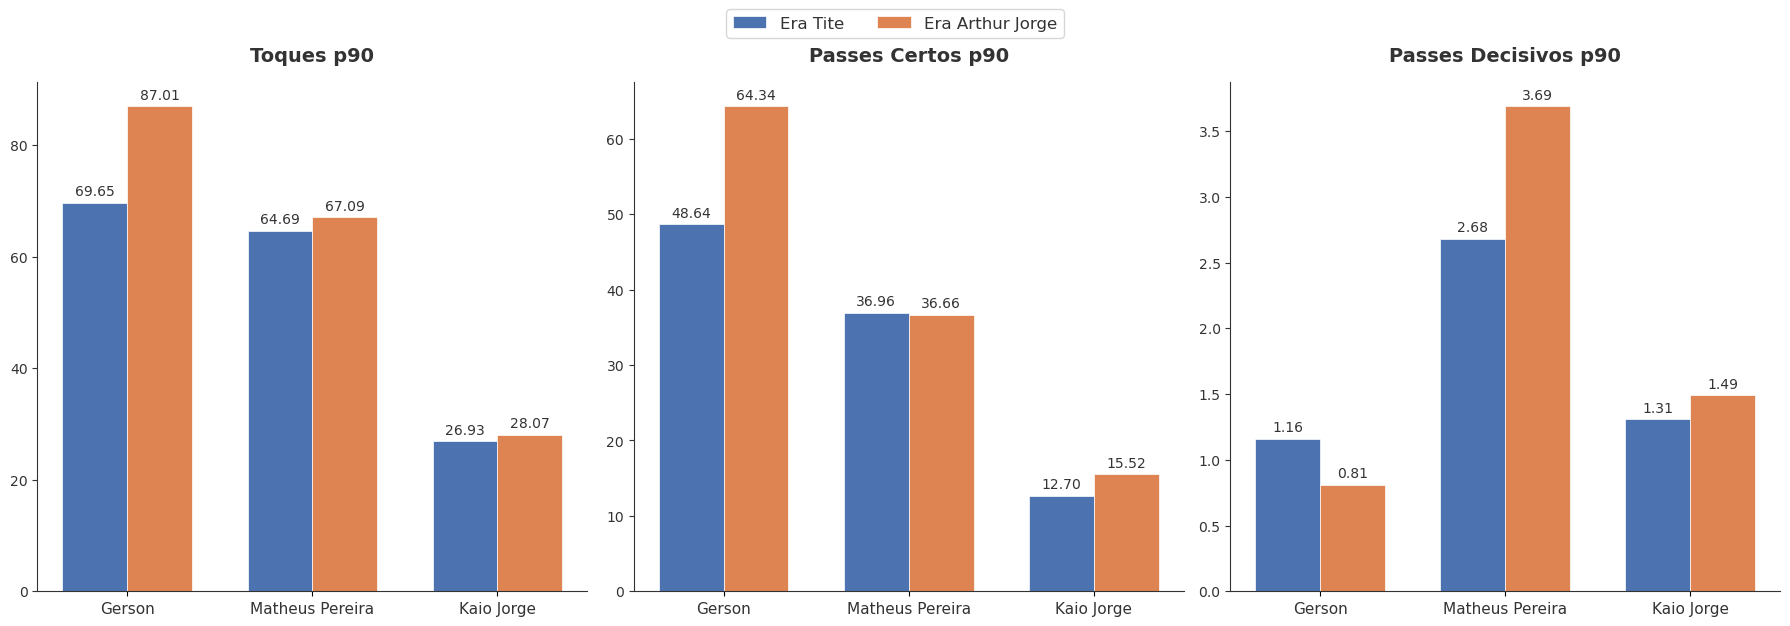

In [47]:
import matplotlib.pyplot as plt
import numpy as np

# Configurando o estilo e as cores (Padrão Corporativo Clássico / Clean)
cor_fundo = '#ffffff'    # Fundo branco puro
cor_tite = '#4c72b0'     # Azul suave (clássico em Data Viz)
cor_arthur = '#dd8452'   # Laranja/Coral (excelente contraste com o azul)
cor_texto = '#333333'    # Cinza muito escuro (melhor que preto puro para leitura)

# Preparando os dados
jogadores = df_final['Jogador'].tolist()
x = np.arange(len(jogadores))  # Localização das barras
width = 0.35  # Largura das barras

# Criando um painel com 3 gráficos lado a lado (1 para cada métrica)
fig, axs = plt.subplots(1, 3, figsize=(18, 6), facecolor=cor_fundo)

metricas = [
    ('Toques p90', 'Toques p90 (Tite)', 'Toques p90 (Arthur)'),
    ('Passes Certos p90', 'Passes Certos p90 (Tite)', 'Passes Certos p90 (Arthur)'),
    ('Passes Decisivos p90', 'Passes Decisivos p90 (Tite)', 'Passes Decisivos p90 (Arthur)')
]

# Loop para plotar cada um dos 3 gráficos
for i, (titulo, col_tite, col_arthur) in enumerate(metricas):
    ax = axs[i]
    ax.set_facecolor(cor_fundo)
    
    # Desenhando as barras
    barras_tite = ax.bar(x - width/2, df_final[col_tite], width, label='Era Tite', color=cor_tite, edgecolor='white', linewidth=0.5)
    barras_arthur = ax.bar(x + width/2, df_final[col_arthur], width, label='Era Arthur Jorge', color=cor_arthur, edgecolor='white', linewidth=0.5)
    
    # Ajustando textos e eixos
    ax.set_title(titulo, color=cor_texto, fontsize=14, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(jogadores, color=cor_texto, fontsize=11)
    ax.tick_params(axis='y', colors=cor_texto)
    
    # Removendo bordas para ficar limpo
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(cor_texto)
    ax.spines['bottom'].set_color(cor_texto)
    
    # Adicionando o valor exato no topo de cada barra para não perdermos o dado da tabela
    for barra in barras_tite + barras_arthur:
        altura = barra.get_height()
        ax.annotate(f'{altura:.2f}',
                    xy=(barra.get_x() + barra.get_width() / 2, altura),
                    xytext=(0, 3),  # 3 points de distância vertical
                    textcoords="offset points",
                    ha='center', va='bottom', color=cor_texto, fontsize=10)

# Adicionando uma única legenda para o painel todo
handles, labels = axs[0].get_legend_handles_labels()
# Linha da legenda ajustada para o fundo claro
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2, 
           facecolor=cor_fundo, edgecolor='#cccccc', labelcolor=cor_texto, fontsize=12)

# Ajustando o layout para não encavalar
plt.tight_layout()
plt.show()

In [17]:
import pandas as pd
import json
import os

def calcular_totais_absolutos(pasta, sigla, nome_busca):
    total_minutos = 0
    total_toques = 0
    total_keypasses = 0
    total_passes = 0
    
    for i in range(1, 9):
        caminho = os.path.join(pasta, f"jogo{i}_{sigla}_lineups.json")
        if os.path.exists(caminho):
            with open(caminho, 'r', encoding='utf-8') as f:
                dados = json.load(f)
                
                # Junta os jogadores dos dois times para buscar
                jogadores = dados['home']['players'] + dados['away']['players']
                
                for j in jogadores:
                    # Busca o jogador pelo nome ignorando maiúsculas
                    if nome_busca.lower() in j['player']['name'].lower():
                        stats = j.get('statistics', {})
                        total_minutos += stats.get('minutesPlayed', 0)
                        total_toques += stats.get('touches', 0)
                        total_keypasses += stats.get('keyPass', 0)
                        total_passes += stats.get('accuratePass', 0)
                        
    return [total_minutos, total_toques, total_passes, total_keypasses]

# Jogadores que vamos analisar
jogadores = ['Gerson', 'Matheus Pereira', 'Kaio Jorge']
resultados_absolutos = []

for jogador in jogadores:
    # Coletando totais absolutos Era Tite
    stats_tite = calcular_totais_absolutos('dados_tite', 'tt', jogador)
    # Coletando totais absolutos Era Arthur Jorge
    stats_arthur = calcular_totais_absolutos('dados_arthur', 'aj', jogador)
    
    resultados_absolutos.append({
        'Jogador': jogador,
        'Minutos (Tite)': stats_tite[0],
        'Minutos (Arthur)': stats_arthur[0],
        'Key Passes (Tite)': stats_tite[3],
        'Key Passes (Arthur)': stats_arthur[3],
        'Passes Certos (Tite)': stats_tite[2],
        'Passes Certos (Arthur)': stats_arthur[2],
        'Toques (Tite)': stats_tite[1],
        'Toques (Arthur)': stats_arthur[1]
    })

# Exibindo a tabela de números brutos
df_absolutos = pd.DataFrame(resultados_absolutos)
display(df_absolutos)

,Jogador,Minutos (Tite),Minutos (Arthur),Key Passes (Tite),Key Passes (Arthur),Passes Certos (Tite),Passes Certos (Arthur),Toques (Tite),Toques (Arthur)
0,Gerson,544,663,7,6,294,474,421,641
1,Matheus Pereira,672,707,20,29,276,288,483,527
2,Kaio Jorge,411,545,6,9,58,94,123,170


In [23]:
import pandas as pd
import json
import os

def calcular_xg_xa(pasta, sigla, nome_busca):
    total_xg = 0
    total_xa = 0
    
    for i in range(1, 9):
        caminho = os.path.join(pasta, f"jogo{i}_{sigla}_lineups.json")
        if os.path.exists(caminho):
            with open(caminho, 'r', encoding='utf-8') as f:
                dados = json.load(f)
                
                jogadores = dados['home']['players'] + dados['away']['players']
                
                for j in jogadores:
                    if nome_busca.lower() in j['player']['name'].lower():
                        stats = j.get('statistics', {})
                        # Somando as métricas de qualidade de chance
                        total_xg += stats.get('expectedGoals', 0)
                        total_xa += stats.get('expectedAssists', 0)
                        
    return total_xg, total_xa

# Vamos focar na dupla de definição: Matheus Pereira e Kaio Jorge
jogadores_ataque = ['Matheus Pereira', 'Kaio Jorge']
resultados_avancados = []

for jogador in jogadores_ataque:
    xg_tite, xa_tite = calcular_xg_xa('dados_tite', 'tt', jogador)
    xg_arthur, xa_arthur = calcular_xg_xa('dados_arthur', 'aj', jogador)
    
    resultados_avancados.append({
        'Jogador': jogador,
        'xA - Assist. Esperadas (Tite)': round(xa_tite, 2),
        'xA - Assist. Esperadas (Arthur)': round(xa_arthur, 2),
        'xG - Gols Esperados (Tite)': round(xg_tite, 2),
        'xG - Gols Esperados (Arthur)': round(xg_arthur, 2)
    })

# Exibindo a tabela de métricas avançadas
df_avancado = pd.DataFrame(resultados_avancados)
display(df_avancado)

,Jogador,xA - Assist. Esperadas (Tite),xA - Assist. Esperadas (Arthur),xG - Gols Esperados (Tite),xG - Gols Esperados (Arthur)
0,Matheus Pereira,1.61,2.80,1.07,1.97
1,Kaio Jorge,0.17,0.51,1.58,3.37


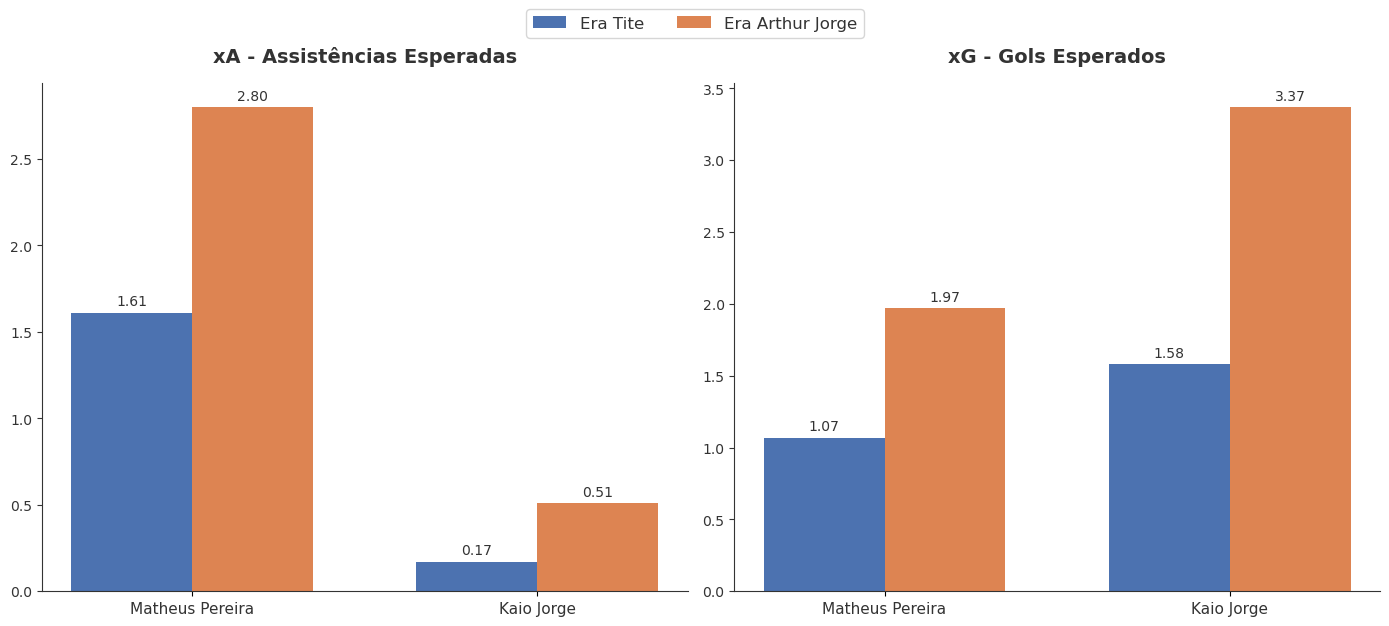

In [49]:
import matplotlib.pyplot as plt
import numpy as np

# Configurando o estilo corporativo
cor_fundo = '#ffffff'
cor_tite = '#4c72b0'
cor_arthur = '#dd8452'
cor_texto = '#333333'

# Pegando os jogadores do dataframe (Matheus e Kaio)
jogadores_xg = df_avancado['Jogador'].tolist()
x = np.arange(len(jogadores_xg))
width = 0.35

fig, axs = plt.subplots(1, 2, figsize=(14, 6), facecolor=cor_fundo)

metricas_xg = [
    ('xA - Assistências Esperadas', 'xA - Assist. Esperadas (Tite)', 'xA - Assist. Esperadas (Arthur)'),
    ('xG - Gols Esperados', 'xG - Gols Esperados (Tite)', 'xG - Gols Esperados (Arthur)')
]

for i, (titulo, col_tite, col_arthur) in enumerate(metricas_xg):
    ax = axs[i]
    ax.set_facecolor(cor_fundo)
    
    barras_tite = ax.bar(x - width/2, df_avancado[col_tite], width, label='Era Tite', color=cor_tite)
    barras_arthur = ax.bar(x + width/2, df_avancado[col_arthur], width, label='Era Arthur Jorge', color=cor_arthur)
    
    ax.set_title(titulo, color=cor_texto, fontsize=14, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(jogadores_xg, color=cor_texto, fontsize=11)
    ax.tick_params(axis='y', colors=cor_texto)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(cor_texto)
    ax.spines['bottom'].set_color(cor_texto)
    
    for barra in barras_tite + barras_arthur:
        altura = barra.get_height()
        ax.annotate(f'{altura:.2f}', xy=(barra.get_x() + barra.get_width() / 2, altura),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', color=cor_texto, fontsize=10)

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2, 
           facecolor=cor_fundo, edgecolor='#cccccc', labelcolor=cor_texto, fontsize=12)

plt.tight_layout()
plt.show()

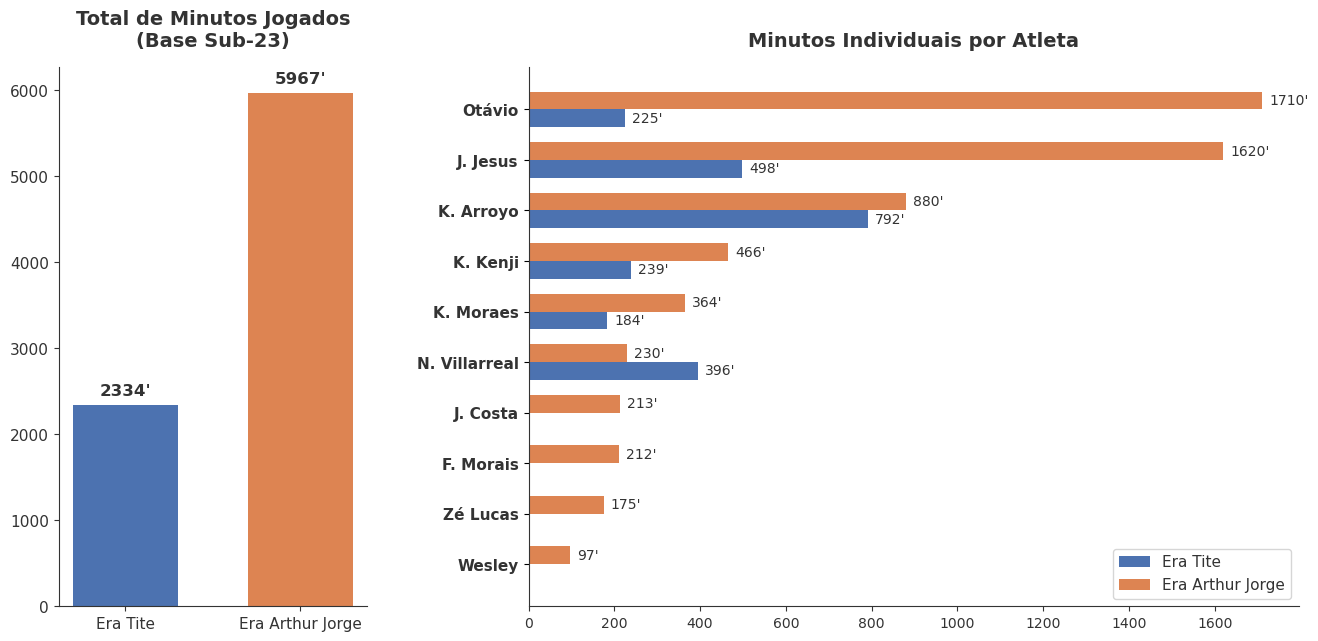

In [55]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Cores (Padrão Corporativo Clássico que definimos)
cor_fundo = '#ffffff'
cor_tite = '#4c72b0'
cor_arthur = '#dd8452'
cor_texto = '#333333'

# Calculando totais
total_tite = sum(base_tite.values())
total_arthur = sum(base_arthur.values())

# Preparando dados individuais para o gráfico horizontal
todos_jogadores = list(set(base_tite.keys()).union(set(base_arthur.keys())))
dados_jogadores = {
    'Jogador': todos_jogadores,
    'Tite': [base_tite.get(j, 0) for j in todos_jogadores],
    'Arthur Jorge': [base_arthur.get(j, 0) for j in todos_jogadores]
}
df_jogadores = pd.DataFrame(dados_jogadores)
# Ordenar pelos minutos do Arthur Jorge (decrescente de cima para baixo no gráfico)
df_jogadores = df_jogadores.sort_values(by=['Arthur Jorge', 'Tite'], ascending=True)

fig = plt.figure(figsize=(16, 7), facecolor=cor_fundo)
# Criando um grid dinâmico: a coluna dos jogadores será mais larga para acomodar os nomes
gs = fig.add_gridspec(1, 2, width_ratios=[1, 2.5], wspace=0.3)

# ---------------------------------------------------
# GRÁFICO 1: TOTAL DE MINUTOS (Esquerda)
# ---------------------------------------------------
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(cor_fundo)

barras_total = ax1.bar(['Era Tite', 'Era Arthur Jorge'], [total_tite, total_arthur], 
                       color=[cor_tite, cor_arthur], width=0.6)

ax1.set_title('Total de Minutos Jogados\n(Base Sub-23)', color=cor_texto, fontsize=14, fontweight='bold', pad=15)
ax1.tick_params(colors=cor_texto, labelsize=11)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color(cor_texto)
ax1.spines['bottom'].set_color(cor_texto)

# Anotando os totais
for barra in barras_total:
    altura = barra.get_height()
    ax1.annotate(f"{int(altura)}'", 
                 xy=(barra.get_x() + barra.get_width() / 2, altura),
                 xytext=(0, 5), textcoords="offset points",
                 ha='center', va='bottom', color=cor_texto, fontsize=12, fontweight='bold')

# ---------------------------------------------------
# GRÁFICO 2: MINUTOS POR JOGADOR (Direita)
# ---------------------------------------------------
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(cor_fundo)

y = np.arange(len(df_jogadores))
altura_barra = 0.35

barras_j_tite = ax2.barh(y - altura_barra/2, df_jogadores['Tite'], altura_barra, label='Era Tite', color=cor_tite)
barras_j_arthur = ax2.barh(y + altura_barra/2, df_jogadores['Arthur Jorge'], altura_barra, label='Era Arthur Jorge', color=cor_arthur)

ax2.set_title('Minutos Individuais por Atleta', color=cor_texto, fontsize=14, fontweight='bold', pad=15)
ax2.set_yticks(y)
ax2.set_yticklabels(df_jogadores['Jogador'], color=cor_texto, fontsize=11, fontweight='bold')
ax2.tick_params(axis='x', colors=cor_texto)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color(cor_texto)
ax2.spines['bottom'].set_color(cor_texto)

# Adicionando os valores na ponta das barras horizontais
for barra in barras_j_tite + barras_j_arthur:
    largura = barra.get_width()
    if largura > 0: # Só anota se o jogador tiver entrado em campo
        ax2.annotate(f"{int(largura)}'", 
                     xy=(largura, barra.get_y() + barra.get_height() / 2),
                     xytext=(5, 0), textcoords="offset points",
                     ha='left', va='center', color=cor_texto, fontsize=10)

ax2.legend(loc='lower right', facecolor=cor_fundo, edgecolor='#cccccc', labelcolor=cor_texto, fontsize=11)

plt.show()

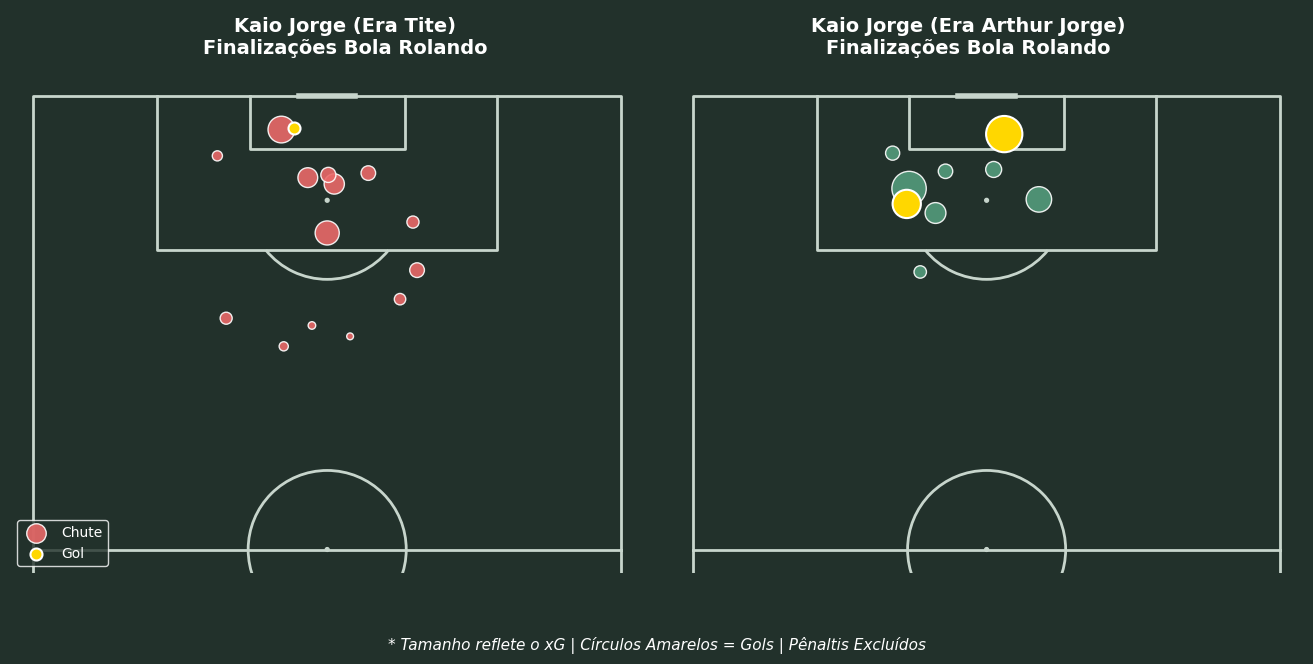

In [37]:
# Configurando o desenho de MEIO CAMPO na vertical
pitch = VerticalPitch(pitch_type='opta', half=True, pitch_color='#22312b', line_color='#c7d5cc')
fig, axs = pitch.grid(ncols=2, title_height=0.08, endnote_space=0, axis=False, figheight=7)
fig.set_facecolor('#22312b')

# ==========================
# PLOT: ERA TITE
# ==========================
# Chutes Normais (Bolinhas Vermelhas) - alpha ajustado para 0.9
pitch.scatter(x_ng_tt, y_ng_tt, s=xg_ng_tt, c='#ea6969', edgecolors='white', linewidths=1, alpha=0.9, ax=axs['pitch'][0], zorder=3, label='Chute')
# Gols (Bolinhas Douradas)
pitch.scatter(x_g_tt, y_g_tt, s=xg_g_tt, c='#ffd700', edgecolors='white', linewidths=1.5, alpha=1.0, ax=axs['pitch'][0], zorder=4, label='Gol')

axs['title'].text(0.25, 0.5, 'Kaio Jorge (Era Tite)\nFinalizações Bola Rolando', color='white', va='center', ha='center', fontsize=14, fontweight='bold')
axs['pitch'][0].legend(loc='lower left', facecolor='#22312b', edgecolor='white', labelcolor='white')

# ==========================
# PLOT: ERA ARTHUR JORGE
# ==========================
# Chutes Normais (Bolinhas Verdes) - alpha ajustado para 0.9
pitch.scatter(x_ng_aj, y_ng_aj, s=xg_ng_aj, c='#539b7c', edgecolors='white', linewidths=1, alpha=0.9, ax=axs['pitch'][1], zorder=3)
# Gols (Bolinhas Douradas)
pitch.scatter(x_g_aj, y_g_aj, s=xg_g_aj, c='#ffd700', edgecolors='white', linewidths=1.5, alpha=1.0, ax=axs['pitch'][1], zorder=4)

axs['title'].text(0.75, 0.5, 'Kaio Jorge (Era Arthur Jorge)\nFinalizações Bola Rolando', color='white', va='center', ha='center', fontsize=14, fontweight='bold')

# Legenda Geral corrigida
fig.text(0.5, 0.02, '* Tamanho reflete o xG | Círculos Amarelos = Gols | Pênaltis Excluídos', color='white', ha='center', fontsize=11, fontstyle='italic')

plt.show()